In the name of God

# Q1: Unsupervised learning and domain adaptation using GAN

## 1-1. Introduction

In this notebook we are going to be performing domain adaptation using GAN following the work done in this paper (https://arxiv.org/abs/1612.05424).

In a nutshell we will use a GAN to adapt the images from one dataset to another, for this task we will use the MNIST dataset which is black and white and adapt it to MNIST-M which has colorized digits and backgrounds.

## 1-2. Theoretical section

Before beginning the code we are going to be answering a few questions

### 1-2-1. GAN instability

#### 1-2-1-1. Why GAN training is unstable?

GAN training is unstable because it is not like other neural networks as it is not a simple optimization problem, instead we have to find an equilibrium between two neural networks opposing each other. In this process we put a generator against a discriminator and they have to compete with each other and become better in the process. But if one of them get too much stronger than the other the whole process would fail.

#### 1-2-1-2. Main reasons of instability


The three main factors of instability in GAN training are:

__1. Mode collapse__    

This is one of the most common failures in GAN and it happens when the generator discovers one or a few outputs that are particularly good at fooling the discriminator. It then begins to only generate samples from those particular classes and ignores the rest of the data. For example, if we want our GAN to generate images of digits, it might find that '1' is easier to generate and begin to only '1' and end up making perfect '1's but ignoring the rest of the digits.

This happens because the generator's goal is to fool the discriminator and if it finds a blind spot, it wouldn't have any intensive to explore other methods (classes)

__2. Vanishing gradient__

This happens when the discriminator learns to distinguish fake and real inputs too quickly. If this happens the discriminator's accuracy reaches almost a 100% while its gradient becomes almost 0. In order for the generator to learn how to fool the discriminator, the gradients are passed down to it form the discriminator, but if the gradients of the discriminator are almost 0 (vanishes!), the generator wouldn't get much information to learn from and can't improve. Thus make the learning process unstable.

__3. Non-convergence__

This happens when instead of reaching a stable point where both the generator and the discriminator are both performing well, the model may get stuck in a loop where the loss values oscillate without ever converging.

#### 1-2-1-3. Counters of instability

__1. Architectural decisions__

Choosing the right architecture can have a pivotal role in model stability, for example using deep convolutional GANs like the one used in the paper may result in a more stable training process.

__2. Loss function__

Using the original minimax loss function may result in instability in some applications. So using alternatives like "Wassertein loss" (which prevents vanishing gradients by using a different measure of distance between distributions) or "Least-Squares loss" (which penalizes the samples are far from the real decision boundaries more and gives a better idea to the generator on how to improve) may help

__3. Regularization and training strategies__

Using task specific losses (like in the paper), regularization or other methods (like adding noise to the discriminator's input or label) may also be useful when dealing with training instability.

### 1-2-2. Why the paper doesn't only use noise as the generator's input?

In a typical GAN, the generator only uses a random noise vector as the input and learns how to transform it into believable outputs, this is a good method for generating new samples from a dataset but if we want to move one image from one domain to another, we would need a different approach.

Only using a noise vector gives little control over the output. Which is why the paper conditions the GAN on an image from the domain we want to translate, this allows us the model to separate the contents from the style. During the learning phase the model learns that the input image provides the content (in our case indicates what the number should be) and the noise controls the style variation. This way we effectively can generate and unlimited number of samples with varying styles but similar (in context) to the input image.

### 1-2-3. Model components

#### 1-2-3-1. Roles of the model components

The model introduced in the paper has three main components (as shown in the image below):

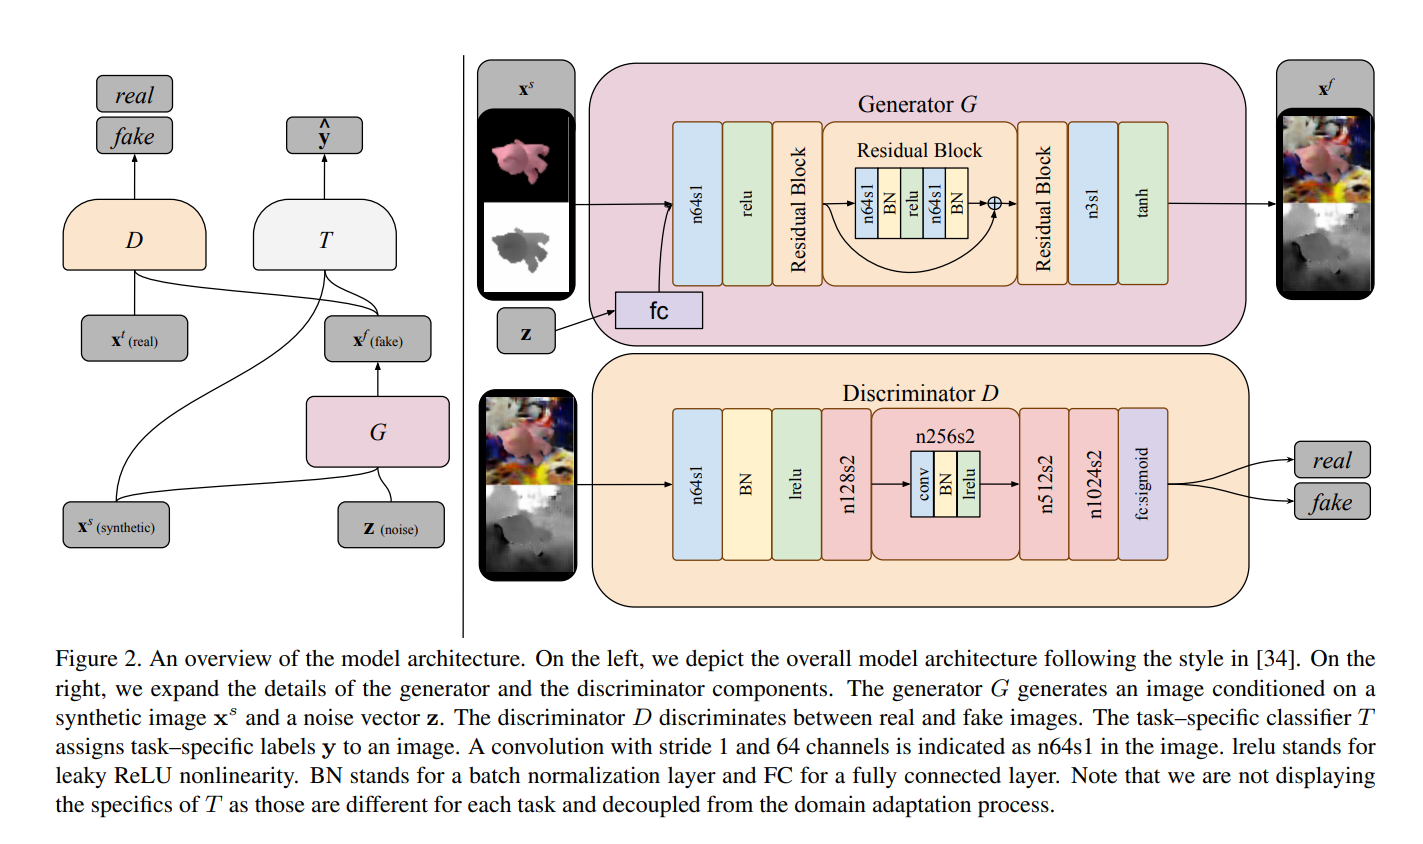

__1. Generator__ 

This is the image translator, its job is to get an image from the source domain (in our case MNIST) as well as a noise vector and transform it to an image that looks as if it was sampled from the target domain (in out case MNIST-M) that can fool the discriminator.

__2. Discriminator__

The discriminator's job is to check the authenticity of images. When it's given an image, it labels them as "real" or "fake" and tries to detect the fake images created by the generator. The feedback from the discriminator is what helps the generator to produce better images.

__3. Classifier__

This is the model that is going to perform our desired task (in our case detecting the digits in our images). It is trained on both the real images form the target domain and the fake images generated by the generator. This forces the generator to create images that not only look good but also preserve the content (for example it makes sure that during translation a 1 wouldn't become a 7!).



#### 1-2-3-2. How the performance would change if one component was removed

If the __generator were removed__ the entire process would be impossible as it is the core component that is responsible for domain translations. Without it we could only train a classifier on the source domain which would perform poorly due to domain shift (as stated in the paper this method is used when we don't have labeled data from the target domain or it's expensive to acquire such data)

If the __discriminator were removed__ the generator would lose its adversarial feedback and thus wouldn't have any incentive to make the output images look like they belong to the target domain. It would only be trained by the classifier and would learn to generate images that the classifier can detect, these images would most likely not resemble the style of the target (MNIST-M) dataset.

If the __classifier were removed__ the generator would only be trained to fool the discriminator. It would still learn to generate images that look like they belong in the target domain (MNIST-M) but it would not have any incentive to preserve the content of the input image, as the output images are considered ok as long as they look like they are from the target domain (for example it might change a 1 to a 7 with MNIST-M style). Which is not the target of this research, the point of developing this GAN is to make new instances from the target domain while preserving the labels to be later used for different tasks.

### 1-2-4. Content similarity loss

In the paper a content similarity loss has been introduced which is a specific type of loss that is called masked pairwise mean squared error (PMSE) and aims to ensure that the generated images's content (in our case the digit) is the same as the input image.

#### 1-2-4-1. Why is content similarity loss necessary?

The goal of this study is to come up with a translation between two domains for training a model (classifier) and this requires that the generative model to preserve the labels. If the generator were to change the contents of the input image then the labels wouldn't be conserved and if we fed this mislabeled data to our classifier it would heavily reduce its performance.

#### 1-2-4-2. Generator behavior without this loss

If the content similarity loss were to be removed the generator would need to be only trained by the adversarial loss and the task loss (from the classifier). This might result in the generator to make more significant changes to the content of the input image to better match the target domain and may end up in "shifting class assignments" as stated in the paper. Furthermore omitting this loss may result in training instability as this loss could act as a regularizer.

### 1-2-5. Why not only use generated images for classifier?

The main reason for this approach is to encourage the generator to keep the content of the images intact. If we were to train the classifier only on the generated examples, then it might learn the wrong classes, for example the generator might produce 1's that are like 7 and the classifier (only seeing the fake images) may also believe that the class labeled as 1 has digits looking like 7! Basically this prevents the generator form changing the content of the images and only stick to changing the style.

Furthermore adding extra constraints like this on the optimization problem could make it more stable by acting like a regularizer.

### 1-2-6. Can this method work for domains that differ semantically?

No, this method would most likely fail in such a scenario as this entire approach is based on the assumption that the core contents between the two domains are the same and they only differ in style, making this method essentially a style transfer technique. The content similarity loss and the trining of the classifier both on generated and original images are all done with the aim of guiding the generator to preserve the labels. So if the model were to change this labels none of these methods would be useful. For example in the case of different objects, there wouldn't really be any logical way for the generator to change say a "dog" to a "cat" or in the case different viewpoints, the generator would need understating of the 3D structure of the image, which would require major architectural changes. And language translation isn't often done by GANs instead recurrent neural networks or transformers are used

## 1-3. Practical section

Now we will implement the model discussed in the paper

### 1-3-1. Data preprocessing

Here we will load the MNIST and MNIST-M datasets and perform the necessary preprocessing steps

#### 1-3-1-1. Loading and visualising

We will first load the datasets and visualise 5 corresponding image pairs from them

Since the pkl files were from an older python version, I had to implement (find) a custom function to read them!

MNIST data
Type: <class 'dict'>
Keys: dict_keys([b'images', b'labels'])


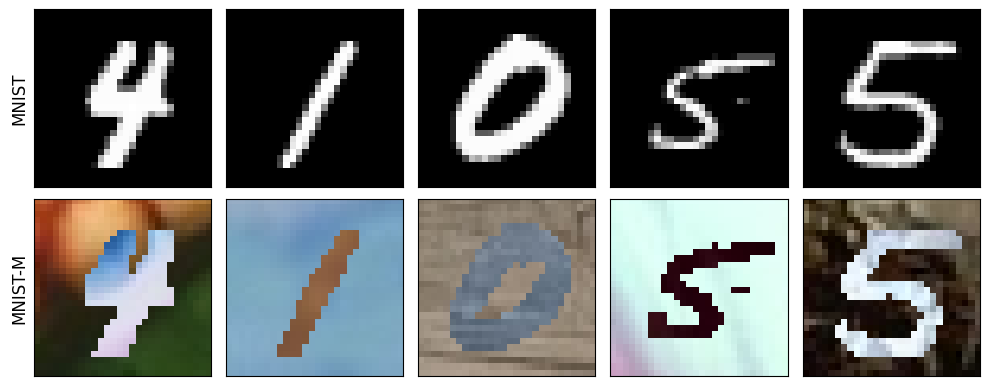

In [38]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

def load_legacy_pickle(file_path):
    class CustomUnpickler(pickle.Unpickler):
        def find_class(self, module, name):
            if name == 'New_ctor' and module == 'numpy.core.multiarray':
                 return np.ndarray.__new__
            try:
                return super().find_class(module, name)
            except AttributeError:
                return None

    with open(file_path, 'rb') as f:
        unpickler = CustomUnpickler(f, encoding='latin1')
        return unpickler.load()

mnist_path = 'dataset/mnist.pkl'
mnist_m_path = 'dataset/mnistm.pkl'

mnist_data = load_legacy_pickle(mnist_path)
mnist_m_data = load_legacy_pickle(mnist_m_path)

print("MNIST data")
print(f"Type: {type(mnist_data)}")
print(f"Keys: {mnist_data.keys()}")

mnist_images, mnist_labels = mnist_data[b'images'], mnist_data[b'labels']
mnist_m_images, mnist_m_labels = mnist_m_data[b'images'], mnist_m_data[b'labels']

num_samples_to_show = 5
indices = np.random.choice(len(mnist_images), num_samples_to_show, replace=False)
fig, axes = plt.subplots(2, num_samples_to_show, figsize=(10, 4))

for i, index in enumerate(indices):
    mnist_image = mnist_images[index]
    mnist_m_image = mnist_m_images[index]

    axes[0, i].imshow(mnist_image, cmap='gray')
    axes[0, i].set_xticks([])
    axes[0, i].set_yticks([])

    axes[1, i].imshow(mnist_m_image)
    axes[1, i].set_xticks([])
    axes[1, i].set_yticks([])

axes[0, 0].set_ylabel('MNIST', fontsize=12)
axes[1, 0].set_ylabel('MNIST-M', fontsize=12)

plt.tight_layout()
plt.show()


#### 1-3-1-2. Preparing and splitting the data for the network

Next we will put the data in separate dataloaders by converting the gray-scale MNIST data to RGB to match MNIST-M, then resize them according to the paper (32x32) and normalise them to the range [-1, 1]

In [39]:
import torch
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import numpy as np

random_state = 24
mnist_labels = mnist_data[b'labels']

num_images = len(mnist_images)
indices = np.arange(num_images)

train_val_indices, test_indices = train_test_split(
    indices, train_size=0.8, test_size=0.2, random_state=random_state
)

train_indices, val_indices = train_test_split(
    train_val_indices, train_size=0.9, test_size=0.1, random_state=random_state
)

print({len(train_indices)})
print({len(val_indices)})
print({len(test_indices)})

image_size = 32
transform_mnist = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])

transform_mnist_m = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])

class ImageDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

mnist_train_dataset = ImageDataset(mnist_images[train_indices], mnist_labels[train_indices], transform=transform_mnist)
mnist_val_dataset = ImageDataset(mnist_images[val_indices], mnist_labels[val_indices], transform=transform_mnist)
mnist_test_dataset = ImageDataset(mnist_images[test_indices], mnist_labels[test_indices], transform=transform_mnist)

mnist_m_train_dataset = ImageDataset(mnist_m_images[train_indices], mnist_labels[train_indices], transform=transform_mnist_m)
mnist_m_val_dataset = ImageDataset(mnist_m_images[val_indices], mnist_labels[val_indices], transform=transform_mnist_m)
mnist_m_test_dataset = ImageDataset(mnist_m_images[test_indices], mnist_labels[test_indices], transform=transform_mnist_m)

batch_size = 32

mnist_train_loader = DataLoader(mnist_train_dataset, batch_size=batch_size, shuffle=True)
mnist_val_loader = DataLoader(mnist_val_dataset, batch_size=batch_size, shuffle=False)
mnist_test_loader = DataLoader(mnist_test_dataset, batch_size=batch_size, shuffle=False)

mnist_m_train_loader = DataLoader(mnist_m_train_dataset, batch_size=batch_size, shuffle=True)
mnist_m_val_loader = DataLoader(mnist_m_val_dataset, batch_size=batch_size, shuffle=False)
mnist_m_test_loader = DataLoader(mnist_m_test_dataset, batch_size=batch_size, shuffle=False)

{50400}
{5600}
{14000}


### 1-3-2. Observing the domain gap

In this section we will implement a classifier according to the given structure in the paper (which can be seen in the image below) and train it on the MNIST dataset but test it on the test portion of MNIST and entire MNIST-M dataset to see the domain gap, which would indicate the baseline performance for our GAN model (we expect to be able to beat this score!)

The hyperparameters were chosen based on the paper.

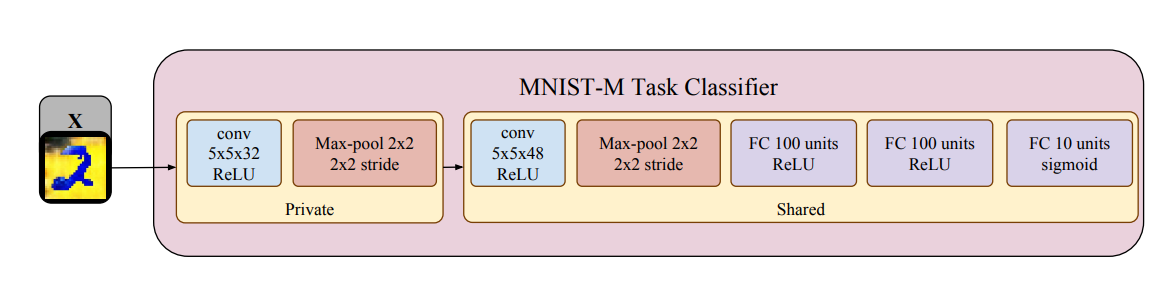

We will first define the necessary functions

In [40]:
import torch.nn as nn

class TaskClassifier(nn.Module):
    def __init__(self):
        super(TaskClassifier, self).__init__()
        self.conv_layers = nn.Sequential(
            # First block
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=5, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Second block
            nn.Conv2d(in_channels=32, out_channels=48, kernel_size=5, stride=1),
            nn.ReLU(), 
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.fc_layers = nn.Sequential(
            nn.Linear(48 * 5 * 5, 100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Linear(100, 10) # We didn't use sigmoid as it is included in cross entropy
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

In [41]:
def evaluate(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in data_loader:
            data, target = data.to(device), target.to(device, dtype=torch.long)
            output = model(data)
            total_loss += criterion(output, target).item() * data.size(0)
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
            
    avg_loss = total_loss / total
    accuracy = 100 * correct / total
    return avg_loss, accuracy

In [42]:
def train_and_validate(
        model, 
        train_loader, 
        val_loader, 
        criterion, 
        optimizer, 
        num_epochs, 
        device
    ):
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    
    print("Starting training")
    for epoch in range(num_epochs):
        model.train() 
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for data, target in train_loader:
            data, target = data.to(device), target.to(device, dtype=torch.long)
            
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * data.size(0)
            _, predicted = torch.max(output.data, 1)
            total_train += target.size(0)
            correct_train += (predicted == target).sum().item()

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = 100 * correct_train / total_train
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)

        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
        
    return model, history

In [43]:
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    ax1.plot(history['train_loss'], label='Train Loss', linestyle='--')
    ax1.plot(history['val_loss'], label='Validation Loss')
    ax1.set_title('Loss History')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    
    ax2.plot(history['train_acc'], label='Train Accuracy', linestyle='--')
    ax2.plot(history['val_acc'], label='Validation Accuracy')
    ax2.set_title('Accuracy History')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    
    plt.show()    

Now we train the model and plot its validation and loss during training.

Using device: cuda
Starting training
Epoch 1/10 | Train Loss: 0.1414, Train Acc: 95.56% | Val Loss: 0.0502, Val Acc: 98.64%
Epoch 2/10 | Train Loss: 0.0479, Train Acc: 98.55% | Val Loss: 0.0599, Val Acc: 98.25%
Epoch 3/10 | Train Loss: 0.0369, Train Acc: 98.89% | Val Loss: 0.0445, Val Acc: 98.75%
Epoch 4/10 | Train Loss: 0.0315, Train Acc: 99.08% | Val Loss: 0.0610, Val Acc: 98.50%
Epoch 5/10 | Train Loss: 0.0235, Train Acc: 99.26% | Val Loss: 0.0488, Val Acc: 98.75%
Epoch 6/10 | Train Loss: 0.0203, Train Acc: 99.35% | Val Loss: 0.0531, Val Acc: 99.00%
Epoch 7/10 | Train Loss: 0.0180, Train Acc: 99.42% | Val Loss: 0.0496, Val Acc: 98.71%
Epoch 8/10 | Train Loss: 0.0163, Train Acc: 99.47% | Val Loss: 0.0529, Val Acc: 99.07%
Epoch 9/10 | Train Loss: 0.0147, Train Acc: 99.56% | Val Loss: 0.0385, Val Acc: 99.07%
Epoch 10/10 | Train Loss: 0.0133, Train Acc: 99.59% | Val Loss: 0.0590, Val Acc: 98.95%


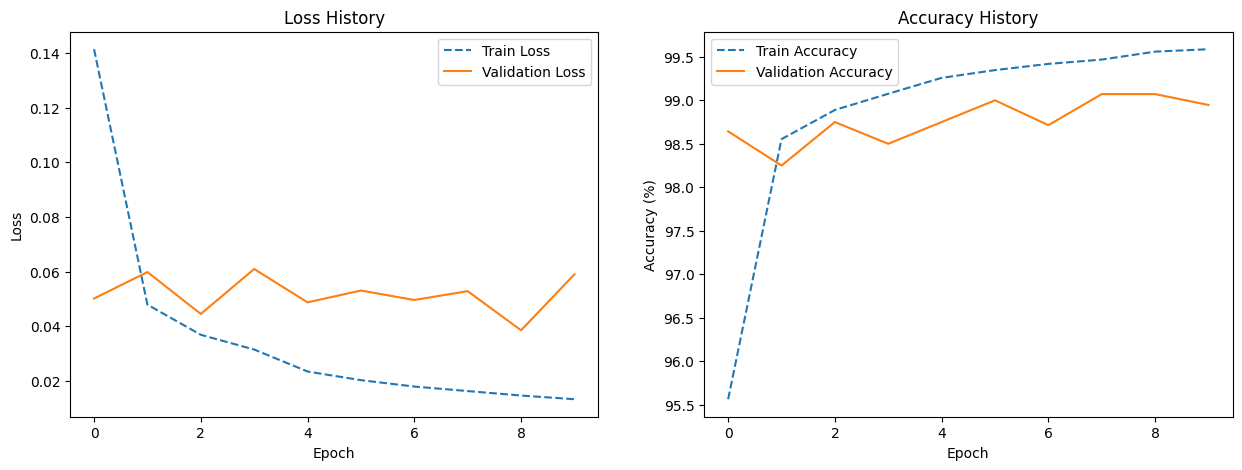

In [44]:
import torch.optim as optim
from torch.utils.data import ConcatDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

baseline_model = TaskClassifier().to(device)
optimizer = optim.Adam(baseline_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
num_epochs = 10

baseline_model, history = train_and_validate(
    model=baseline_model,
    train_loader=mnist_train_loader,
    val_loader=mnist_val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=num_epochs,
    device=device
)
plot_history(history)

As we can see the model has been trained properly and managed to get an accuracy of 99% on the validation dataset! next we test it on the MNIST test data and the entire MNIST-M dataset.

In [45]:
_, mnist_test_accuracy = evaluate(baseline_model, mnist_test_loader, criterion, device)
print(f"Accuracy on MNIST test set: {mnist_test_accuracy:.2f}%")

full_mnist_m_dataset = ConcatDataset([mnist_m_train_dataset, mnist_m_test_dataset])
full_mnist_m_loader = DataLoader(full_mnist_m_dataset, batch_size=32, shuffle=False)
_, mnist_m_accuracy = evaluate(baseline_model, full_mnist_m_loader, criterion, device)
print(f"Accuracy on full MNIST-M dataset: {mnist_m_accuracy:.2f}%")

Accuracy on MNIST test set: 98.84%
Accuracy on full MNIST-M dataset: 60.99%


We can see the model performance on MNIST test set was 98% which shows it has been trained well, but the accuracy on the MNIST-M dataset was only 60% showing the domain shift between these two datasets.

### 1-3-3. Implementing the model architecture

In this section we are going to implement the 3 main components of the model: Generator (G), Discriminator (D) and the Task Classifier (T) based on the material provided in the paper (the images below)

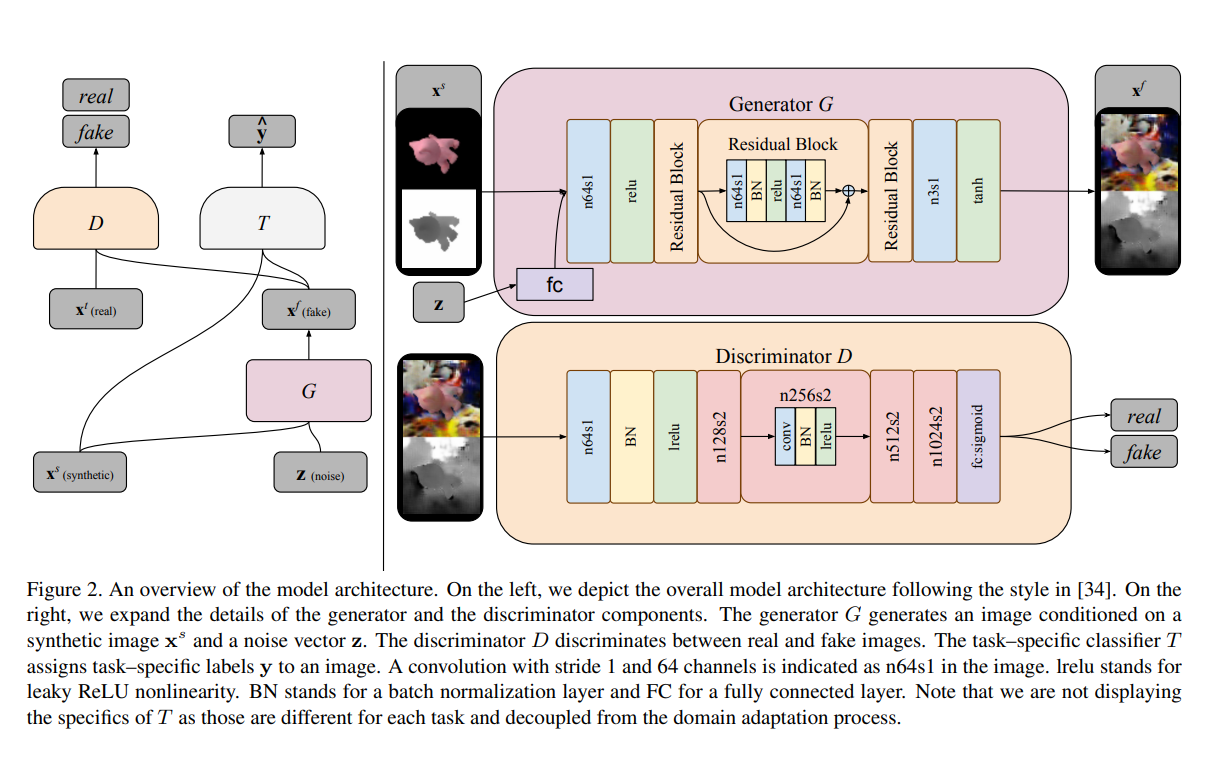

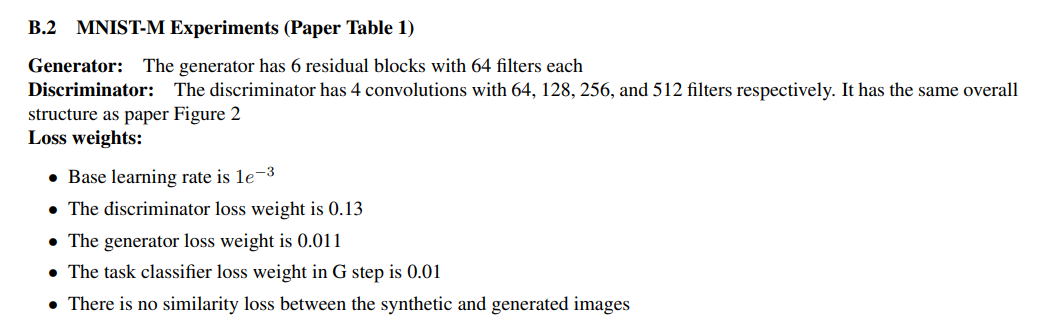

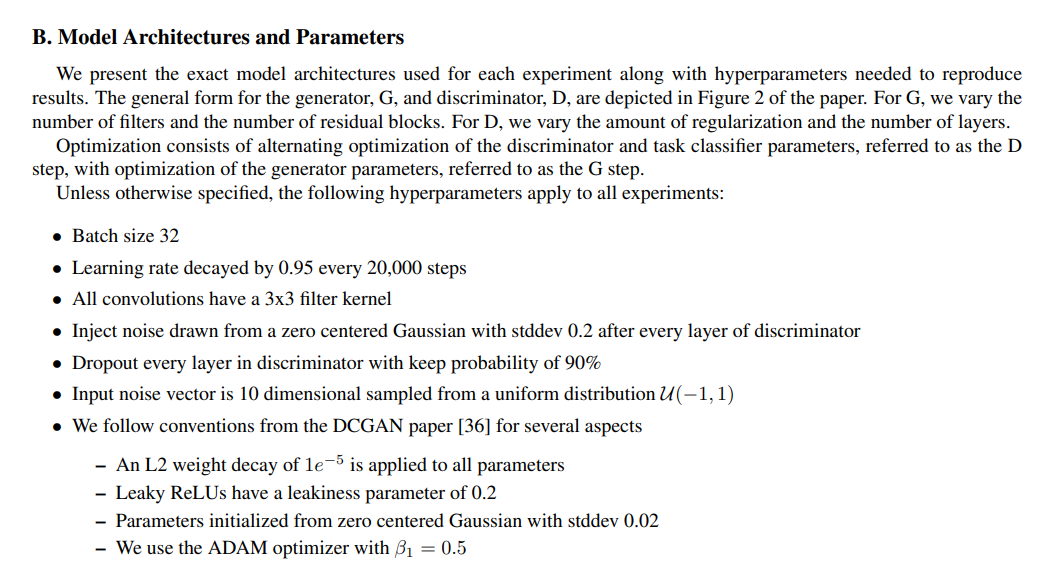

#### 1-3-3-1. Generator (G)

According to the paper the generator has a UNet-like architecture with 6 residual blocks and 64 filters in its convolutional layers. It takes both a source image and a 10-dimensional noise vector.

In [46]:
class ResidualBlock(nn.Module):
    def __init__(self, in_features):
        super(ResidualBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_features, in_features, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(in_features),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_features, in_features, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(in_features),
        )

    def forward(self, x):
        return x + self.block(x)

class Generator(nn.Module):
    def __init__(self, input_channels=3, z_dim=10, num_residual_blocks=6):
        super(Generator, self).__init__()
        self.fc_noise = nn.Linear(z_dim, 32 * 32)
        
        self.conv1 = nn.Sequential(
            nn.Conv2d(input_channels + 1, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
        )

        res_blocks = []
        for _ in range(num_residual_blocks):
            res_blocks.append(ResidualBlock(64))
        self.res_blocks = nn.Sequential(*res_blocks)

        self.conv_out = nn.Sequential(
            nn.Conv2d(64, 3, kernel_size=3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, image, z):
        model_device = next(self.parameters()).device
        image = image.to(model_device)
        z = z.to(model_device)
        
        noise_channel = self.fc_noise(z).view(z.size(0), 1, 32, 32)
        x = torch.cat((image, noise_channel), 1)
        x = self.conv1(x)
        x = self.res_blocks(x)
        x = self.conv_out(x)
        
        return x

#### 1-3-3-2. Discriminator (D)

The Discriminator is a standard convolutional network that classifies an image as either real (from the target domain) or fake (from the Generator). It has 4 convolutional layers with increasing filter sizes (64, 128, 256, 512) and a final fully connected layer for the classification output.

In [47]:
class Discriminator(nn.Module):
    def __init__(self, input_channels=3):
        super(Discriminator, self).__init__()
        
        def discriminator_block(in_filters, out_filters, bn=True, stride=2):
            block = [nn.Conv2d(in_filters, out_filters, kernel_size=3, stride=stride, padding=1)]
            if bn:
                block.append(nn.BatchNorm2d(out_filters))
            block.append(nn.LeakyReLU(0.2, inplace=True))
            block.append(nn.Dropout2d(0.1))
            return block

        self.model = nn.Sequential(
            *discriminator_block(input_channels, 64, bn=False, stride=1),
            *discriminator_block(64, 128, stride=2),
            *discriminator_block(128, 256, stride=2),
            *discriminator_block(256, 512, stride=2),
        )

        self.adv_layer = nn.Sequential(
            nn.Linear(512 * 4 * 4, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        out = self.model(img)
        out = out.view(out.shape[0], -1)
        validity = self.adv_layer(out)
        return validity

#### 1-3-3-3. Task Classifier (T)

It has the same architecture from before (I've copy and pasted it, but it had to be changed slightly to be implemented in the GAN structure)

In [48]:
class TaskClassifier(nn.Module):
    def __init__(self):
        super(TaskClassifier, self).__init__()
        self.private_block = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        
        self.shared_block_conv = nn.Sequential(
            nn.Conv2d(32, 48, kernel_size=5, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.shared_block_fc = nn.Sequential(
            nn.Linear(48 * 5 * 5, 100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Linear(100, 10)
        )

    def forward(self, x):
        x = self.private_block(x)
        x = self.shared_block_conv(x)
        x = x.view(x.size(0), -1)
        x = self.shared_block_fc(x)
        return x

In [49]:
print("Generator")
G = Generator()
print(G)

print("Discriminator")
D = Discriminator()
print(D)

print("\n Task Classifier")
T = TaskClassifier()
print(T)

Generator
Generator(
  (fc_noise): Linear(in_features=10, out_features=1024, bias=True)
  (conv1): Sequential(
    (0): Conv2d(4, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
  )
  (res_blocks): Sequential(
    (0): ResidualBlock(
      (block): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (1): ResidualBlock(
      (block): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 

### 1-3-4. Cost functions

The training for this motel is a two step process that alternates between training the generator (G) and training the discriminator(D) and classier (T).

In the first step we treat the generator as fixed and train the other two components. The discriminator would try to get better at telling real images form fake ones generated by the generator, thus it's fed both images form the target domain and produced by the generator and it uses the __adversarial loss (binary cross entropy)__ for training. The classifier would try to get better at identifying the digits and is fed both images from the the original source (MNIST) and ones generated by the generator (to force the generator to preserve the content (digit)) and for this task it uses the __task loss (cross entropy)__.

In the second step the generator is updated to get batter at both fooling the discriminator (matching the style of the target domain) and helping the classifier get better (preserving the content), it uses the __adversarial loss__ for the first task and __task loss__ for the latter.

This losses are combined using predefined weights (hyper parameter), these values can be seen int the B2 section of the paper (the image below).

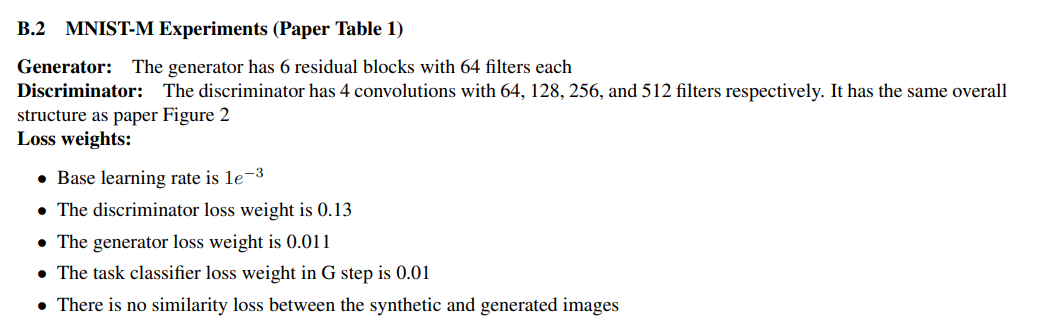

For our task we use the binary cross entropy loss as the adversarial loss and the cross entropy loss as the task loss

In [50]:
adversarial_loss = nn.BCELoss() 

task_loss = nn.CrossEntropyLoss()

class Hyperparameters:
    def __init__(self):
        self.lr = 1e-3
        self.b1 = 0.5  
        self.b2 = 0.999 
        self.n_cpu = 8 
        self.latent_dim = 10 
        self.img_size = 32
        self.channels = 3
        
        
        self.loss_d_weight = 0.13
        self.loss_g_adv_weight = 0.011
        self.loss_g_task_weight = 0.01

hyperparameters = Hyperparameters()

adversarial_loss.to(device)
task_loss.to(device)

CrossEntropyLoss()

### 1-3-5. Training the model

Now we will train the model as explained before (first training the discriminator, then the classifier and the generator), we will also define a save_checkpoint function to save the model every 5 epochs so we can keep the best model.

One important point to note here is that in order to simulate real world situations we shouldn't be plotting the accuracy and loss on the test data during our training and we shouldn't let the test data influence our training process, but for educational proposes I've plotted them!

In [ ]:
import os

def save_checkpoint(
        epoch, 
        generator, 
        discriminator, 
        classifier, 
        optim_g,
        optim_d, 
        optim_t, 
        folder="checkpoints"
    ):
    if not os.path.exists(folder):
        os.makedirs(folder)
    
    checkpoint_path = os.path.join(folder, f"checkpoint_epoch_{epoch}.pth")
    torch.save({
        'epoch': epoch,
        'generator_state_dict': generator.state_dict(),
        'discriminator_state_dict': discriminator.state_dict(),
        'classifier_state_dict': classifier.state_dict(),
        'optimizer_g_state_dict': optim_g.state_dict(),
        'optimizer_d_state_dict': optim_d.state_dict(),
        'optimizer_t_state_dict': optim_t.state_dict(),
    }, checkpoint_path)
    print(f"Saved checkpoint for epoch {epoch} at {checkpoint_path}")

In [ ]:
G = G.to(device)
D = D.to(device)
T = T.to(device)

optimizer_G = torch.optim.Adam(G.parameters(), lr=hyperparameters.lr, betas=(hyperparameters.b1, hyperparameters.b2))
optimizer_D = torch.optim.Adam(D.parameters(), lr=hyperparameters.lr, betas=(hyperparameters.b1, hyperparameters.b2))
optimizer_T = torch.optim.Adam(T.parameters(), lr=hyperparameters.lr, betas=(hyperparameters.b1, hyperparameters.b2))

num_epochs = 25
history = { 
    'G_loss': [],
    'D_loss': [],
    'T_loss': [],
    'source_val_acc': [],
    'target_val_acc': [],
    'source_train_acc': [],
    'target_train_acc': [],
    'source_test_acc': [],
    'target_test_acc': [],
}

print("\n Starting Adversarial Training ")
for epoch in range(num_epochs):
    G.train()
    D.train()
    T.train()
    
    g_loss_epoch, d_loss_epoch, t_loss_epoch = 0, 0, 0

    for i, ((source_images, source_labels), (target_images, _)) in enumerate(zip(mnist_train_loader, mnist_m_train_loader)):
        
        source_images = source_images.to(device)
        source_labels = source_labels.to(device, dtype=torch.long)
        target_images = target_images.to(device)

        batch_size = source_images.size(0)
        valid = torch.ones(batch_size, 1, device=device, requires_grad=False)
        fake = torch.zeros(batch_size, 1, device=device, requires_grad=False)

        z = torch.randn(batch_size, hyperparameters.latent_dim, device=device)
        fake_imgs = G(source_images, z)

        # Training the Discriminator 
        optimizer_D.zero_grad()
        loss_real = adversarial_loss(D(target_images), valid)
        loss_fake = adversarial_loss(D(fake_imgs.detach()), fake)
        d_loss = (loss_real + loss_fake) * 0.5 * hyperparameters.loss_d_weight
        d_loss.backward()
        optimizer_D.step()
        
        # Training the Classifier 
        optimizer_T.zero_grad()
        loss_real_task = task_loss(T(source_images), source_labels)
        loss_fake_task = task_loss(T(fake_imgs.detach()), source_labels)
        t_loss = (loss_real_task + loss_fake_task) * 0.5
        t_loss.backward()
        optimizer_T.step()
        
        # Training the Generator
        optimizer_G.zero_grad()
        g_adv_loss = adversarial_loss(D(fake_imgs), valid)
        g_task_loss = task_loss(T(fake_imgs), source_labels)
        g_loss = (g_adv_loss * hyperparameters.loss_g_adv_weight) + (g_task_loss * hyperparameters.loss_g_task_weight)
        g_loss.backward()
        optimizer_G.step()
        
        g_loss_epoch += g_loss.item()
        d_loss_epoch += d_loss.item()
        t_loss_epoch += t_loss.item()

    avg_g_loss = g_loss_epoch / len(mnist_train_loader)
    avg_d_loss = d_loss_epoch / len(mnist_train_loader)
    avg_t_loss = t_loss_epoch / len(mnist_train_loader)
    history['G_loss'].append(avg_g_loss)
    history['D_loss'].append(avg_d_loss)
    history['T_loss'].append(avg_t_loss)

    T.eval()
    _, source_val_acc = evaluate(T, mnist_val_loader, task_loss, device)
    _, target_val_acc = evaluate(T, mnist_m_val_loader, task_loss, device)
    history['source_val_acc'].append(source_val_acc)
    history['target_val_acc'].append(target_val_acc)

    _, source_train_acc = evaluate(T, mnist_train_loader, task_loss, device)
    _, target_train_acc = evaluate(T, mnist_m_train_loader, task_loss, device)
    history['source_train_acc'].append(source_train_acc)
    history['target_train_acc'].append(target_train_acc)
    
    _, source_test_acc = evaluate(T, mnist_test_loader, task_loss, device)
    _, target_test_acc = evaluate(T, mnist_m_test_loader, task_loss, device)
    history['source_test_acc'].append(source_test_acc)
    history['target_test_acc'].append(target_test_acc)

    print(f"[Epoch {epoch+1}/{num_epochs}] "
          f"[D loss: {avg_d_loss:.4f}] [G loss: {avg_g_loss:.4f}] [T loss: {avg_t_loss:.4f}] "
          f"[Source Acc: {source_val_acc:.2f}%] [Target Acc: {target_val_acc:.2f}%]")

    if (epoch + 1) % 5 == 0:
        save_checkpoint(epoch + 1, G, D, T, optimizer_G, optimizer_D, optimizer_T)

print(" Adversarial Training Finished ")


 Starting Adversarial Training 
[Epoch 1/25] [D loss: 0.0562] [G loss: 0.0384] [T loss: 0.2379] [Source Acc: 98.52%] [Target Acc: 88.50%]
[Epoch 2/25] [D loss: 0.0332] [G loss: 0.0576] [T loss: 0.0968] [Source Acc: 98.16%] [Target Acc: 91.14%]
[Epoch 3/25] [D loss: 0.0290] [G loss: 0.0648] [T loss: 0.0612] [Source Acc: 98.82%] [Target Acc: 91.32%]
[Epoch 4/25] [D loss: 0.0223] [G loss: 0.0711] [T loss: 0.0507] [Source Acc: 98.82%] [Target Acc: 91.45%]
[Epoch 5/25] [D loss: 0.0188] [G loss: 0.0758] [T loss: 0.0451] [Source Acc: 98.82%] [Target Acc: 92.43%]
Saved checkpoint for epoch 5 at checkpoints/checkpoint_epoch_5.pth
[Epoch 6/25] [D loss: 0.0152] [G loss: 0.0827] [T loss: 0.0418] [Source Acc: 98.88%] [Target Acc: 93.18%]
[Epoch 7/25] [D loss: 0.0163] [G loss: 0.0796] [T loss: 0.0354] [Source Acc: 98.88%] [Target Acc: 92.46%]
[Epoch 8/25] [D loss: 0.0143] [G loss: 0.0838] [T loss: 0.0344] [Source Acc: 98.86%] [Target Acc: 93.54%]
[Epoch 9/25] [D loss: 0.0128] [G loss: 0.0887] [T lo

### 1-3-6. Shoring the results

In this section we will first plot the data during our training (accuracy and loss), then we will show 5 images alongside the output of the generator for that corresponding image and show the classifier's prediction for all of them to have a visual verification of the results

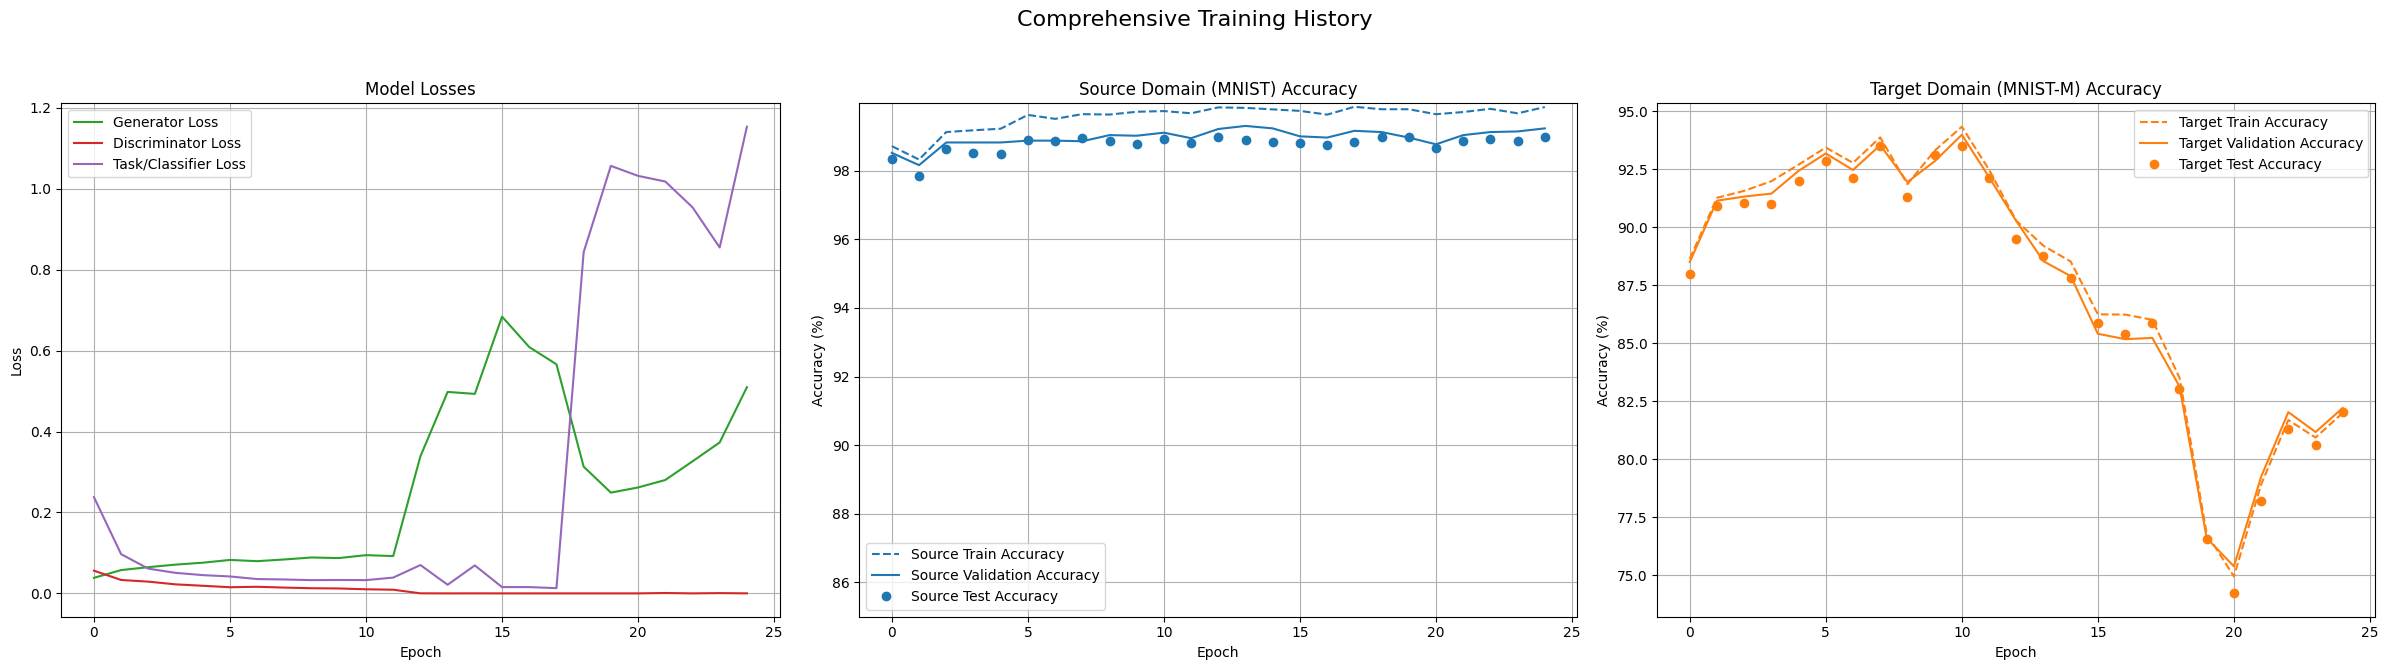

In [56]:
def plot_full_history(history):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 7))
    fig.suptitle("Comprehensive Training History", fontsize=16)

    ax1.plot(history['G_loss'], label='Generator Loss', color='C2')
    ax1.plot(history['D_loss'], label='Discriminator Loss', color='C3')
    ax1.plot(history['T_loss'], label='Task/Classifier Loss', color='C4')
    ax1.set_title('Model Losses')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(history['source_train_acc'], label='Source Train Accuracy', color='C0', linestyle='--')
    ax2.plot(history['source_val_acc'], label='Source Validation Accuracy', color='C0')
    ax2.plot(history['source_test_acc'], label='Source Test Accuracy', color='C0', marker='o', linestyle='None')
    ax2.set_title('Source Domain (MNIST) Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_ylim(bottom=min(85, int(min(history['source_train_acc']))))
    ax2.legend()
    ax2.grid(True)

    ax3.plot(history['target_train_acc'], label='Target Train Accuracy', color='C1', linestyle='--')
    ax3.plot(history['target_val_acc'], label='Target Validation Accuracy', color='C1')
    ax3.plot(history['target_test_acc'], label='Target Test Accuracy', color='C1', marker='o', linestyle='None')
    ax3.set_title('Target Domain (MNIST-M) Accuracy')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Accuracy (%)')
    ax3.legend()
    ax3.grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

plot_full_history(history)

From the middle plots we can see that from the beginning the performance of the classifier was quite good (98+ %) on the source domain but looking at the right had plot we can see that the performance of the target domain wasn't quite as good and it kept increasing till epoch 10 where the model begin diverging and the accuracy of the target domain began reducing drastically. This can be explained by looking at the loss plot (the left hand plot) where we can see the gradient of the discriminator went almost to zero (and "vanishing gradient" which was explained earlier happened!)

So in order to showcase the best results we will be loading the checkpoint after epoch 10 and visualise the results of the generator. 

In [60]:
def load_checkpoint(
        checkpoint_path, 
        generator, 
        discriminator, 
        classifier, 
        optim_g, 
        optim_d, 
        optim_t, 
        device
    ):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    generator.load_state_dict(checkpoint['generator_state_dict'])
    discriminator.load_state_dict(checkpoint['discriminator_state_dict'])
    classifier.load_state_dict(checkpoint['classifier_state_dict'])
    
    optim_g.load_state_dict(checkpoint['optimizer_g_state_dict'])
    optim_d.load_state_dict(checkpoint['optimizer_d_state_dict'])
    optim_t.load_state_dict(checkpoint['optimizer_t_state_dict'])
    
    start_epoch = checkpoint['epoch']
    
    
    generator.eval()
    discriminator.eval()
    classifier.eval()
    
    return start_epoch

G = Generator().to(device)
D = Discriminator().to(device)
T = TaskClassifier().to(device)

optimizer_G = torch.optim.Adam(G.parameters(), lr=hyperparameters.lr, betas=(hyperparameters.b1, hyperparameters.b2))
optimizer_D = torch.optim.Adam(D.parameters(), lr=hyperparameters.lr, betas=(hyperparameters.b1, hyperparameters.b2))
optimizer_T = torch.optim.Adam(T.parameters(), lr=hyperparameters.lr, betas=(hyperparameters.b1, hyperparameters.b2))

checkpoint_to_load = "checkpoints/checkpoint_epoch_10.pth"

load_checkpoint(checkpoint_to_load, G, D, T, optimizer_G, optimizer_D, optimizer_T, device)

10

Classifier accuracy:
Accuracy on Source Train: 99.72%
Accuracy on Source Validation: 99.02%
Accuracy on Source Test: 98.79%
Accuracy on Target Train: 93.30%
Accuracy on Target Validation: 92.84%
Accuracy on Target Test: 93.11%
----------------------------------------


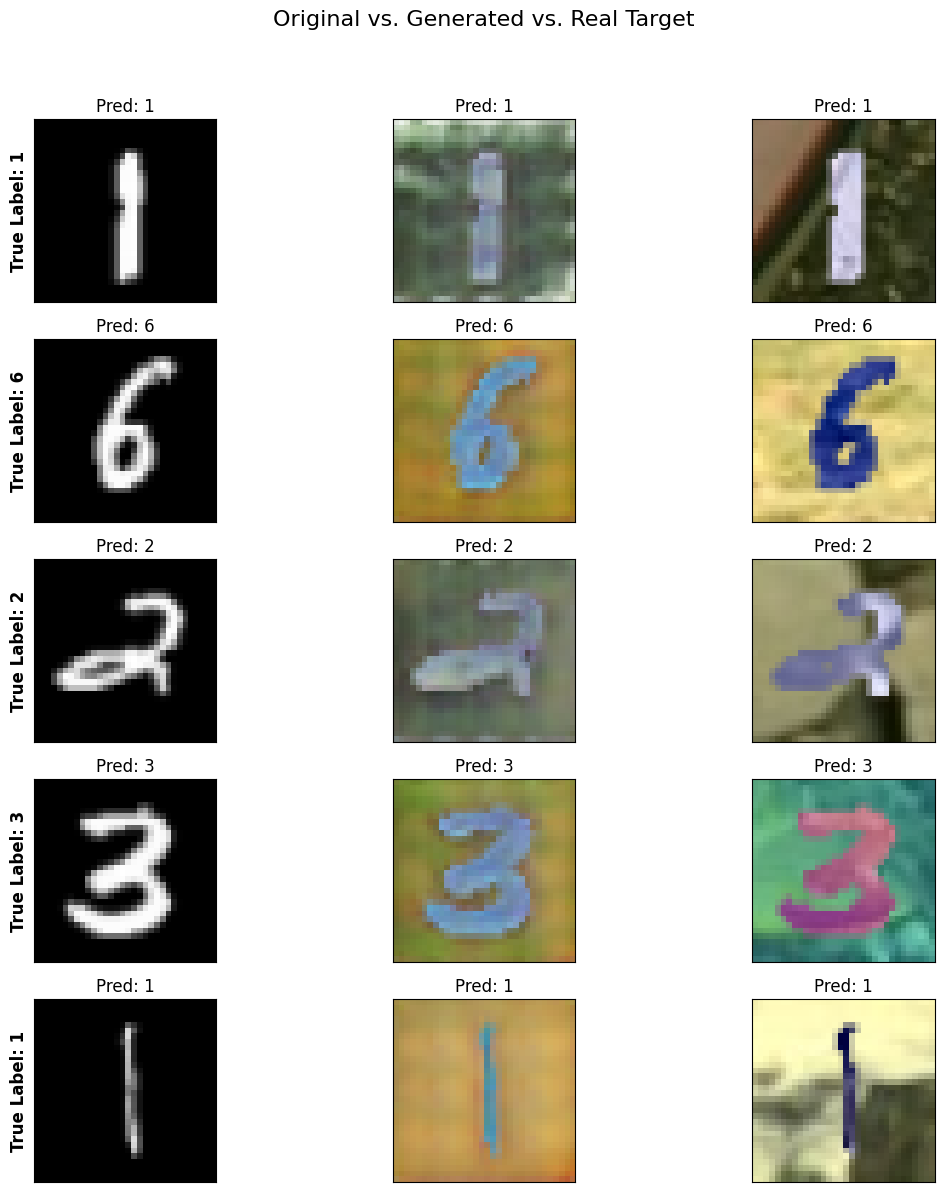

In [63]:
def denorm(tensor):
    return tensor * 0.5 + 0.5

def display_and_evaluate_results(
    generator,
    classifier,
    dataloaders,
    device,
    hyperparameters,
    num_samples=5
):
    print("Classifier accuracy:")
    classifier.eval() 
    for name, loader in dataloaders.items():
        _, accuracy = evaluate(classifier, loader, task_loss, device)
        print(f"Accuracy on {name}: {accuracy:.2f}%")
    print("----------------------------------------")

    generator.eval()
    
    source_images, source_labels = next(iter(dataloaders['Source Test']))
    target_images, _ = next(iter(dataloaders['Target Test']))

    indices = np.random.choice(len(source_images), num_samples, replace=False)
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 2.5 * num_samples))
    fig.suptitle("Original vs. Generated vs. Real Target", fontsize=16)
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            source_image = source_images[idx].unsqueeze(0).to(device)
            true_label = source_labels[idx].item()
            real_target_image = target_images[idx].unsqueeze(0).to(device)

            z = torch.randn(1, hyperparameters.latent_dim, device=device)
            generated_img = generator(source_image, z)
            
            pred_source_out = classifier(source_image)
            _, pred_source = torch.max(pred_source_out.data, 1)

            pred_generated_out = classifier(generated_img)
            _, pred_generated = torch.max(pred_generated_out.data, 1)

            pred_target_out = classifier(real_target_image)
            _, pred_target = torch.max(pred_target_out.data, 1)

            display_source = denorm(source_image.squeeze().cpu()).permute(1, 2, 0)
            display_generated = denorm(generated_img.squeeze().cpu()).permute(1, 2, 0)
            display_target = denorm(real_target_image.squeeze().cpu()).permute(1, 2, 0)
            
            axes[i, 0].imshow(display_source)
            axes[i, 0].set_title(f"Pred: {pred_source.item()}")
            
            axes[i, 1].imshow(display_generated)
            axes[i, 1].set_title(f"Pred: {pred_generated.item()}")
            
            axes[i, 2].imshow(display_target)
            axes[i, 2].set_title(f"Pred: {pred_target.item()}")
            
            axes[i, 0].set_ylabel(f"True Label: {true_label}", fontsize=12, weight='bold')

            for ax in axes[i]:
                ax.set_xticks([])
                ax.set_yticks([])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

all_dataloaders = {
    'Source Train': mnist_train_loader,
    'Source Validation': mnist_val_loader,
    'Source Test': mnist_test_loader,
    'Target Train': mnist_m_train_loader,
    'Target Validation': mnist_m_val_loader,
    'Target Test': mnist_m_test_loader,
}

display_and_evaluate_results(
    generator=G,
    classifier=T,
    dataloaders=all_dataloaders,
    device=device,
    hyperparameters=hyperparameters
)

As we can see the images produced by the generator are quite good and closely resemble the MNIST-M style and have preserved the content.

The accuracy of the model is quite good too both on source domain test (98.8%) and the target domain test (93%)